# EE446 - TinyML - Assignment 2

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

I0000 00:00:1780511649.038419    1817 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780511649.039074    1817 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780511649.129285    1817 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780511651.814456    1817 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## Reading Data

In [2]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [3]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [4]:
data = data.drop(['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'], axis = 1)

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [5]:
data['attack'] = data['attack'].apply(
    lambda x: 'normal' if x == 'normal' else 'attack')

In [6]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [7]:
for col in ['protocoltype', 'service', 'flag', 'attack']:
    data[col] = LabelEncoder().fit_transform(data[col])

In [8]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [9]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

X_test shape: (25195, 38)
y_test shape: (25195,)
labels: [0 1]
attack points: 13564
normal points: 11631


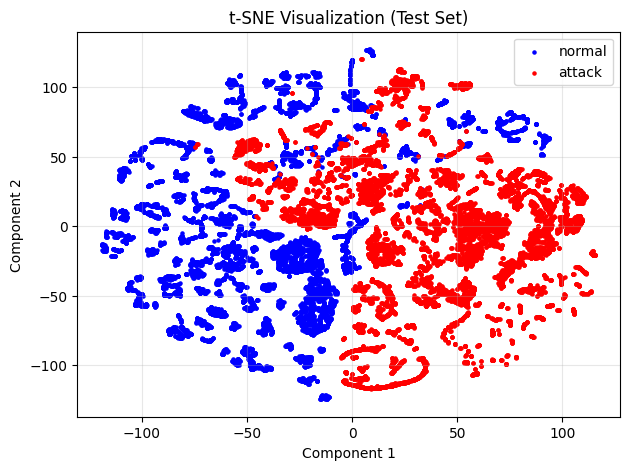

In [10]:
from sklearn.manifold import TSNE
## INSERT YOUR CODE HERE ##
# ensure arrays
X_test = np.array(X_test)
y_test = np.array(y_test).ravel()

# safety check
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("labels:", np.unique(y_test))

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_test)

# masks (adjust if needed)
attack_mask = (y_test == 1)
normal_mask = (y_test == 0)

print("attack points:", np.sum(attack_mask))
print("normal points:", np.sum(normal_mask))

# plot
plt.figure(figsize=(7,5))

plt.scatter(X_tsne[normal_mask, 0], X_tsne[normal_mask, 1],
            c='blue', s=5, label='normal')

plt.scatter(X_tsne[attack_mask, 0], X_tsne[attack_mask, 1],
            c='red', s=5, label='attack')

plt.title("t-SNE Visualization (Test Set)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

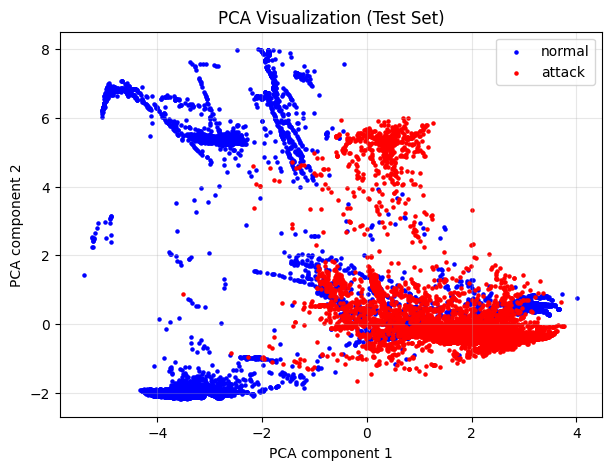

In [11]:
from sklearn.decomposition import PCA
## INSERT YOUR CODE HERE ##
pca = PCA(n_components=2)
pca.fit(X_train)

X_pca = pca.transform(X_test)
y_test = np.array(y_test).ravel()

attack_mask = (y_test == 1)
normal_mask = (y_test == 0)

plt.figure(figsize=(7,5))

plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
            c='blue', s=5, label='normal')

plt.scatter(X_pca[attack_mask, 0], X_pca[attack_mask, 1],
            c='red', s=5, label='attack')

plt.title("PCA Visualization (Test Set)")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

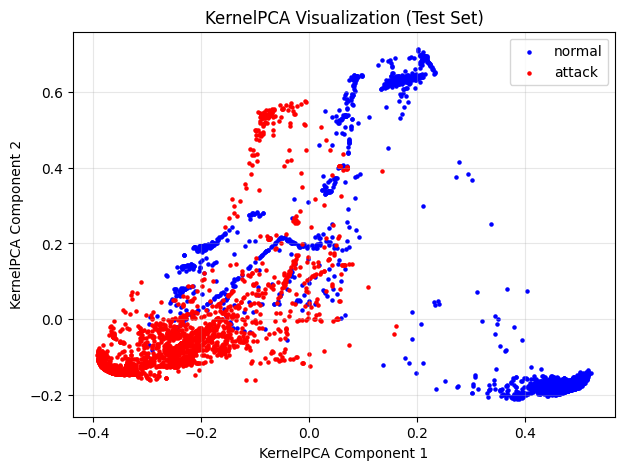

In [12]:
from sklearn.decomposition import KernelPCA
## INSERT YOUR CODE HERE ##
subset_size = 3000
idx = np.random.choice(len(X_train), subset_size, replace=False)

kpca = KernelPCA(
    n_components=2,
    kernel='rbf',
    gamma=0.01
)

kpca.fit(X_train[idx])

X_test_small = X_test[:5000]
y_test_small = np.array(y_test[:5000]).ravel()

X_kpca = kpca.transform(X_test_small)

attack_mask = (y_test_small == 1)
normal_mask = (y_test_small == 0)

plt.figure(figsize=(7, 5))

plt.scatter(
    X_kpca[normal_mask, 0],
    X_kpca[normal_mask, 1],
    c='blue',
    s=5,
    label='normal'
)

plt.scatter(
    X_kpca[attack_mask, 0],
    X_kpca[attack_mask, 1],
    c='red',
    s=5,
    label='attack'
)

plt.title("KernelPCA Visualization (Test Set)")
plt.xlabel("KernelPCA Component 1")
plt.ylabel("KernelPCA Component 2")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [13]:
# Define the DNN model
base_model = Sequential([
    ## INSERT YOUR CODE HERE ##
    Input(shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(2, activation='softmax')
])

E0000 00:00:1780511717.496221    1817 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1780511717.496795    1932 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780511717.533673    1817 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [14]:

## INSERT YOUR CODE HERE ##
base_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

base_model.fit(
    X_train,
    y_train,
    epochs=16, 
    batch_size=8, 
    verbose=1
)

Epoch 1/16
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.9846 - loss: 0.0451
Epoch 2/16
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9950 - loss: 0.0152
Epoch 3/16
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9956 - loss: 0.0129
Epoch 4/16
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9957 - loss: 0.0118
Epoch 5/16
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.9961 - loss: 0.0115
Epoch 6/16
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9963 - loss: 0.0110
Epoch 7/16
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9964 - loss: 0.0105
Epoch 8/16
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9963 - loss: 0.0105
Epoch 9/16
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9965 - loss: 0.0101
Epoch 10/16
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9966 - loss: 0.0102
Epoch 11/16
12598/12598 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9967 - loss: 0.01

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11631
           1       1.00      1.00      1.00     13564

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



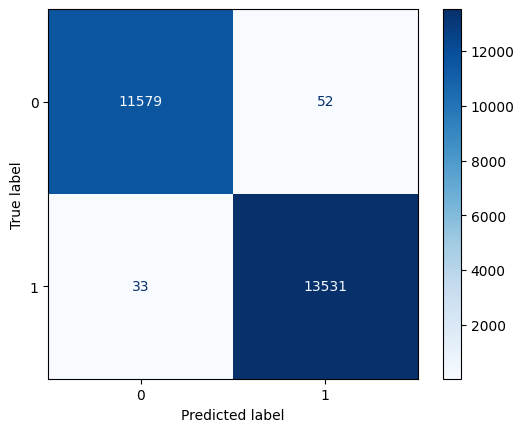

In [25]:
## INSERT YOUR CODE HERE ##
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(
    base_model.predict(X_test, verbose=0), 
    axis=1
)

print(classification_report(y_test, y_pred, zero_division=0))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.show()
#print(confusion_matrix(y_test, y_pred))

In [16]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [17]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

## INSERT YOUR CODE HERE ##
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmp2yqqxur6/assets


INFO:tensorflow:Assets written to: /tmp/tmp2yqqxur6/assets


Saved artifact at '/tmp/tmp2yqqxur6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 38), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  125819481993296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125819481985232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125819481992336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125819481987152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125819481988304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125819481993488: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1780512125.727102    1817 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1780512125.727150    1817 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1780512125.727518    1817 reader.cc:83] Reading SavedModel from: /tmp/tmp2yqqxur6
I0000 00:00:1780512125.727880    1817 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1780512125.727886    1817 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp2yqqxur6
I0000 00:00:1780512125.732957    1817 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1780512125.733611    1817 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1780512125.761449    1817 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp2yqqxur6
I0000 00:00:1780512125.768907    1817 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 41399 microseconds.
I0000 00:00:1780512125.802169    1817

In [18]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 36.00 KB
Quantized model size: 3.54 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11631
           1       1.00      1.00      1.00     13564

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



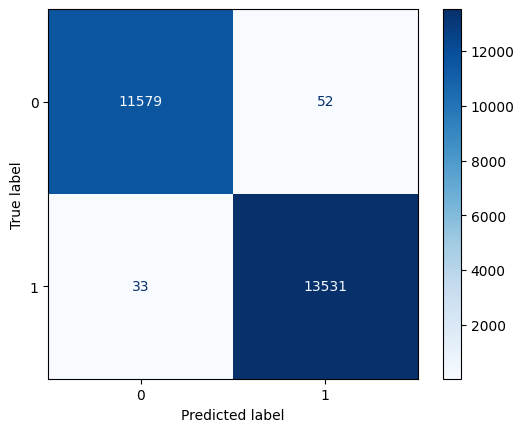

In [26]:
## INSERT YOUR CODE HERE ##
interpreter = tf.lite.Interpreter(model_content = tflite_quant_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
y_pred_quant = []

for i in range (len(X_test)):
    sample = X_test[i].astype(np.float32).reshape(1, -1)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    pred_class = np.argmax(output)
    y_pred_quant.append(pred_class)
y_pred_quant  = np.array(y_pred_quant)

print(classification_report(y_test, y_pred_quant, zero_division = 0))
cm = confusion_matrix(y_test, y_pred_quant)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.show()

## Converting tflite_model to C and create the header file

In [28]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [29]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [30]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462068, -0.01385437126629366, 
    -2.2235805674567635, -0.00776224074056876, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059746, 
    -0.01166364260376003, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.026180024184542783, -0.018609896340735923, 
    -0.041221197593275305, -0.0028174939213690773, -0.0975309439715147, 
    0.5929049025138218, -0.3681102129968653, -0.5252156100627213, 
    -0.6319290328885425, 2.527949242633261, 2.715364578035608, 
    -1.4806560312905028, 5.196207521885405, -0.3745597044055346, 
    0.7343425609306345, -1.0356876376568842, -1.1610301865840364, 
    3.689630622074369, -0.4801968475158174, -0.28910340026287856, 
    -0.5720831756644157, -0.6248707997445304, 1.471730554149434, 
    2.753913722653446, -1.965556401534894, -0.11024922321249885, 
  

In [31]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 5;

const uint8_t y_test[5] = {
    0, 1, 0, 1, 1
};

